In [72]:
import re
import os
from pathlib import Path
import s3fs
import pandas as pd
import numpy as np
import xarray as xr
import rasterio
import geopandas as gpd
import cartopy
import matplotlib.pyplot as plt

import argparse
from collections import defaultdict
from datacube.utils.aws import configure_s3_access

## Set up extended aus albers projection for cartopy figures

In [73]:
"""
We rely on a custom Australian Albers projection here, as the PROJ/cartopy implementation of ESPG:9473/3577 has an upper latitude limit that is too low for the northern extent of the domain.
See https://epsg.io/3577 and https://epsg.io/9473 for information about each of these projections  
For our purposes, a projection based upon the GRS80 ellipsoid is sufficient to mimic either of these projection systems.
"""

aus_albers = cartopy.crs.AlbersEqualArea(
    central_longitude=132,
    standard_parallels=[-18, -36],
    globe=cartopy.crs.Globe(ellipse='GRS80')
)


### import tile files from gdata1

In [74]:
# add link to tile geojson in gdata1
tiles_dir = 'gdata1/data/albers_grids/ga_summary_grid_c3.geojson'
tiles = gpd.read_file(tiles_dir)

tiles_exd_dir = 'gdata1/data/albers_grids/ga_summary_grid_c3_expanded.geojson'
tiles_exd = gpd.read_file(tiles_dir)

# tile geojson downloaded via dea exploerer instad of the gdata versions:
tiles_explorer = gpd.read_file(
    'gdata1/projects/fc-sub-annual/tc_check_temp/ga_ls_tc_pc_cyear_3-regions-aws-explorer.geojson'
)

#  filepath to the txt file from Brad:
tc_tiles = 'gdata1/projects/fc-sub-annual/tc_check_temp/comparison_summary_2024_all.txt'

In [75]:
bounds = tiles_explorer.total_bounds
print(bounds)
print(tiles_explorer.crs)

[111.53308872 -44.34031321 155.07370469  -8.51120628]
EPSG:4326


<GeoAxes: title={'center': 'Tiles from GA Summary Grid (DEA Explorer)'}>

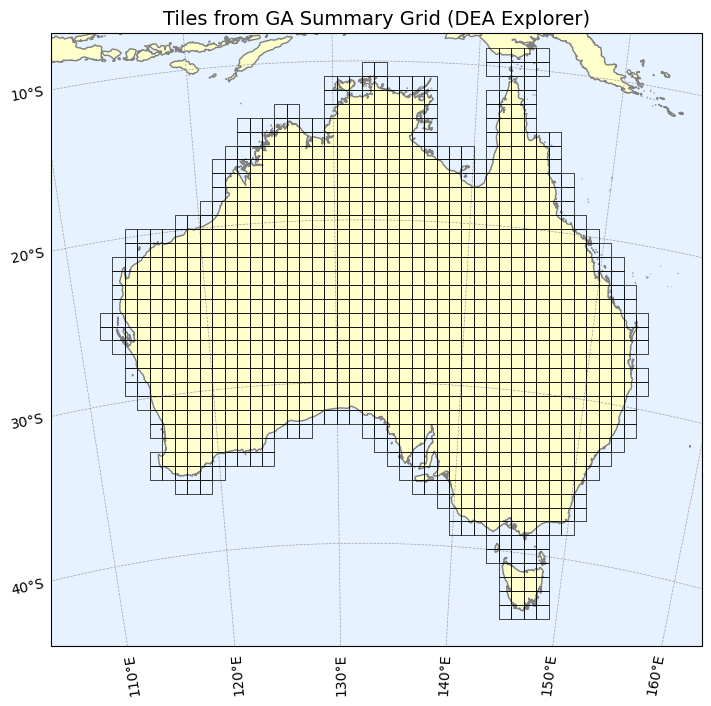

In [76]:
f, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': aus_albers}, constrained_layout=True)
ax.set_title('Tiles from GA Summary Grid (DEA Explorer)', fontsize=14)
ax.set_facecolor('#e6f2ff')
ax.add_feature(cartopy.feature.NaturalEarthFeature(category='physical', name='land', scale='10m',
                                                   facecolor='#ffffcc', edgecolor='#808080'))

ax.set_extent([111, 155, -45, -8], crs=cartopy.crs.PlateCarree())
ax.gridlines(lw=0.5, ls='--', color='#a0a0a0', draw_labels=['left', 'bottom'])

tiles_explorer.plot(ax=ax, facecolor='none', edgecolor='black', lw=0.5, transform=cartopy.crs.CRS(f'{tiles_explorer.crs}'), zorder=2)

In [77]:
with Path(tc_tiles).open('r', encoding='utf-8') as f:
    print(f.read())

Full Comparison Summary for ga_ls_tc_pc_cyear_3
Year: 2024, Band: *, Version: 2-0-0

Total files in original product: 9333
Identical files: 9249
Files with differences: 84
Missing tiles: 0
Errors encountered: 0
Missing folder count: 0
Time taken: 4h 4m 23.90s


FILES WITH DIFFERENCES (84):

File: ga_ls_tc_pc_cyear_3_x28y43_2024--P1Y_final_bright_pc_10.tif
  Path 1: dea-public-data/derivative/ga_ls_tc_pc_cyear_3/2-0-0/x28/y43/2024--P1Y/ga_ls_tc_pc_cyear_3_x28y43_2024--P1Y_final_bright_pc_10.tif
  Path 2: dea-public-data-dev/derivative/ga_ls_tc_pc_cyear_3_test/2-0-0/x28/y43/2024--P1Y/ga_ls_tc_pc_cyear_3_x28y43_2024--P1Y_final_bright_pc_10.tif

File: ga_ls_tc_pc_cyear_3_x29y37_2024--P1Y_final_bright_pc_10.tif
  Path 1: dea-public-data/derivative/ga_ls_tc_pc_cyear_3/2-0-0/x29/y37/2024--P1Y/ga_ls_tc_pc_cyear_3_x29y37_2024--P1Y_final_bright_pc_10.tif
  Path 2: dea-public-data-dev/derivative/ga_ls_tc_pc_cyear_3_test/2-0-0/x29/y37/2024--P1Y/ga_ls_tc_pc_cyear_3_x29y37_2024--P1Y_final_bright_pc_

In [78]:
#parse tile ids from txt file and sace as txt file
def extract_tile_codes(textfile_path):
    pattern = re.compile(r'^File:\s+.*?(x\d+y\d+)', re.IGNORECASE)
    tile_ids = []
    file_paths = []
    seen = set()

    with Path(textfile_path).open('r', encoding='utf-8') as file:
        for line in file:
            match = pattern.search(line)
            if match:
                tile_id = match.group(1)
                file_path = str(line).split('File:')[1].strip()
                if tile_id not in seen:
                    seen.add(tile_id)
                    tile_ids.append(tile_id)
                    file_paths.append(file_path)
    return tile_ids, file_paths

In [79]:
tile_id_list, tile_id_paths = extract_tile_codes(tc_tiles)
print(tile_id_list)
print(len(tile_id_list))

['x28y43', 'x29y37', 'x29y45', 'x30y43', 'x30y44', 'x32y31', 'x32y39', 'x32y48', 'x33y39', 'x34y39', 'x35y45', 'x35y47', 'x36y48', 'x36y50', 'x38y41', 'x39y54', 'x40y48', 'x40y52', 'x41y40', 'x42y45', 'x42y46', 'x43y55', 'x44y45', 'x45y54', 'x45y56', 'x46y36', 'x46y44', 'x46y57', 'x47y37', 'x47y41', 'x47y42', 'x47y45', 'x47y46', 'x47y50', 'x47y53', 'x48y50', 'x48y52', 'x49y40', 'x49y42', 'x49y56', 'x50y35', 'x50y40', 'x50y48', 'x52y33', 'x52y36', 'x52y41', 'x53y31', 'x53y40', 'x53y43', 'x53y50', 'x54y28', 'x54y34', 'x54y43', 'x55y30', 'x55y45', 'x56y31', 'x56y32', 'x56y48', 'x58y23', 'x58y27', 'x58y39', 'x58y43', 'x59y27', 'x59y28', 'x59y38', 'x59y48', 'x60y28', 'x60y40', 'x61y38', 'x62y42', 'x63y36', 'x63y41', 'x63y45', 'x64y37', 'x65y37', 'x67y35', 'x67y40']
77


In [80]:
tile_id_paths

['ga_ls_tc_pc_cyear_3_x28y43_2024--P1Y_final_bright_pc_10.tif',
 'ga_ls_tc_pc_cyear_3_x29y37_2024--P1Y_final_bright_pc_10.tif',
 'ga_ls_tc_pc_cyear_3_x29y45_2024--P1Y_final_bright_pc_10.tif',
 'ga_ls_tc_pc_cyear_3_x30y43_2024--P1Y_final_bright_pc_90.tif',
 'ga_ls_tc_pc_cyear_3_x30y44_2024--P1Y_final_bright_pc_50.tif',
 'ga_ls_tc_pc_cyear_3_x32y31_2024--P1Y_final_bright_pc_50.tif',
 'ga_ls_tc_pc_cyear_3_x32y39_2024--P1Y_final_wet_pc_10.tif',
 'ga_ls_tc_pc_cyear_3_x32y48_2024--P1Y_final_wet_pc_90.tif',
 'ga_ls_tc_pc_cyear_3_x33y39_2024--P1Y_final_wet_pc_10.tif',
 'ga_ls_tc_pc_cyear_3_x34y39_2024--P1Y_final_bright_pc_50.tif',
 'ga_ls_tc_pc_cyear_3_x35y45_2024--P1Y_final_bright_pc_90.tif',
 'ga_ls_tc_pc_cyear_3_x35y47_2024--P1Y_final_bright_pc_90.tif',
 'ga_ls_tc_pc_cyear_3_x36y48_2024--P1Y_final_wet_pc_50.tif',
 'ga_ls_tc_pc_cyear_3_x36y50_2024--P1Y_final_wet_pc_10.tif',
 'ga_ls_tc_pc_cyear_3_x38y41_2024--P1Y_final_bright_pc_10.tif',
 'ga_ls_tc_pc_cyear_3_x39y54_2024--P1Y_final_bright_pc_

In [81]:
#use tile ids to  create geojson with footprints of tiles in the id list
selected_tiles = tiles_explorer[tiles_explorer['region_code'].isin(tile_id_list)]


<GeoAxes: title={'center': 'Tiles flagged as different for TCP 2024 runs'}>

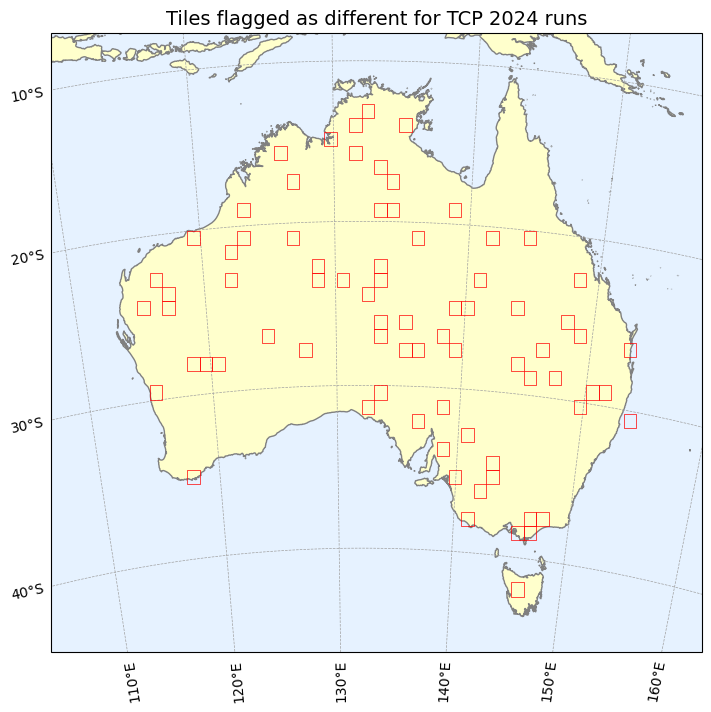

In [82]:
f, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': aus_albers}, constrained_layout=True)
ax.set_title('Tiles flagged as different for TCP 2024 runs', fontsize=14)
ax.set_facecolor('#e6f2ff')
ax.add_feature(cartopy.feature.NaturalEarthFeature(category='physical', name='land', scale='10m',
                                                   facecolor='#ffffcc', edgecolor='#808080'))

ax.set_extent([111, 155, -45, -8], crs=cartopy.crs.PlateCarree())
ax.gridlines(lw=0.5, ls='--', color='#a0a0a0', draw_labels=['left', 'bottom'])

selected_tiles.plot(ax=ax, facecolor='none', edgecolor='red', lw=0.5, transform=cartopy.crs.CRS(f'{selected_tiles.crs}'), zorder=2)

In [83]:
len(selected_tiles)

77

In [84]:
# gqa tile lists from Gianluca

gqa_tcp_dir = 'gdata1/projects/fc-sub-annual/tc_check_temp/tiles_gqa_issue-TCP.csv'
gqa_ls5_dir = 'gdata1/projects/fc-sub-annual/tc_check_temp/tiles_gqa_issue-ls5_7-geomad.csv'

gqa_ls5 = pd.read_csv(gqa_ls5_dir)
gqa_tcp = pd.read_csv(gqa_tcp_dir)

In [85]:
gqa_tcp

,product,year,tile
0,TCP,1987,x38y50
1,TCP,1987,x38y49
2,TCP,1987,x38y48
3,TCP,1988,x38y50
4,TCP,1988,x38y49
5,TCP,1988,x38y48
6,TCP,1989,x38y50
7,TCP,1991,x38y50
8,TCP,1992,x38y50
9,TCP,1993,x38y48


In [86]:
gqa_tcp_list = gqa_tcp['tile'].tolist()
gqa_ls5_list = gqa_ls5['tile'].tolist()

gqa_list = set(gqa_tcp_list + gqa_ls5_list)

In [87]:
gqa_tcp_tiles = tiles_explorer[tiles_explorer['region_code'].isin(gqa_list)]

<GeoAxes: title={'center': 'GQA re-processed tiles from Gianluca'}>

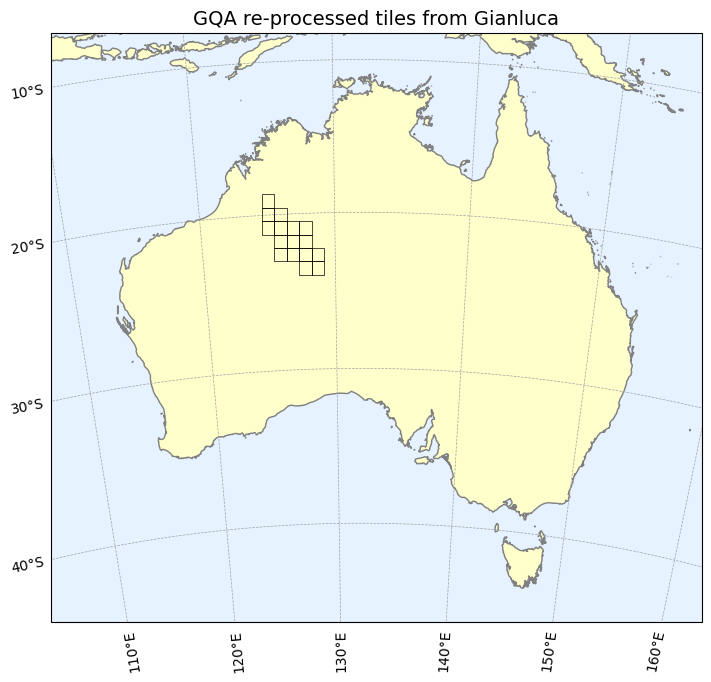

In [88]:
f, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': aus_albers}, constrained_layout=True)

ax.set_title('GQA re-processed tiles from Gianluca', fontsize=14)
ax.set_facecolor('#e6f2ff')
ax.add_feature(cartopy.feature.NaturalEarthFeature(category='physical', name='land', scale='10m',
                                                   facecolor='#ffffcc', edgecolor='#808080'))

ax.set_extent([111, 155, -45, -8], crs=cartopy.crs.PlateCarree())
ax.gridlines(lw=0.5, ls='--', color='#a0a0a0', draw_labels=['left', 'bottom'])

gqa_tcp_tiles.plot(ax=ax, facecolor='none', edgecolor='black', lw=0.5, transform=cartopy.crs.CRS(f'{gqa_tcp_tiles.crs}'), zorder=2)

## investigate some individual tiles to see pixel-absed differences

Note that most of the functions in this section are taken from Brad Greer's fantastic `comparison.py` script and modified to work in this notebook. If they are broken, it's my fault.

In [ ]:
def get_tiles(root_dir: str) -> set:
    unique_pairs = set()
    orig_paths = S3FS.glob(f"{root_dir}/*/*")

    for p in orig_paths:
        # Extract only the last two components, e.g. x34/y48
        x, y = p.rsplit("/", 2)[-2:]
        unique_pairs.add(f"{x}/{y}")
    
    print(f"Retrieved tiles from: {root_dir}\n")
    return unique_pairs

In [125]:
def get_diff_tiles(dir_1:str, dir_2:str, target_tiles_fname: str, output_dir:str):
    orig_paths = get_tiles(dir_1)

    for i in target_tiles_fname:
        x, y = i[20:23], i[23:26]
        print(f"Processing tile: {x}/{y}")
        if f"{x}/{y}" in orig_paths:
            cogs_1 = f"{dir_1}/{x}/{y}/2024--P1Y/{i}"
            cogs_2 = f"{dir_2}/{x}/{y}/2024--P1Y/{i}"

            print(cogs_2)
            try:
                with xr.open_dataset(cogs_1, engine='rasterio') as ds1, \
                xr.open_dataset(cogs_2, engine='rasterio') as ds2:
                    diff = (ds1.to_array() - ds2.to_array()).squeeze()

                    output_fname = os.path.basename(cogs_1).replace('.tif', '_diff.tif')
                    output_path = os.path.join(output_dir, output_fname)

                    diff.rio.to_raster(
                        output_path,
                        driver='COG',
                        compress='deflate'
                    )
            except Exception as e:
                print(f"Error processing tile {i}: {e}")



In [126]:
S3FS = s3fs.S3FileSystem(anon=True)
configure_s3_access(cloud_defaults=True, aws_unsigned=False)

In [130]:
orig_run = 's3://dea-public-data/derivative/ga_ls_tc_pc_cyear_3/2-0-0'
test_run = 's3://dea-public-data-dev/derivative/ga_ls_tc_pc_cyear_3_test/2-0-0'

diff_tif_dir = 'gdata1/projects/fc-sub-annual/tc_check_temp/diff_tifs/'

In [131]:
test_paths = tile_id_paths[:3]
test_ids = tile_id_list[:3]

print(test_ids)
print(test_paths)

['x28y43', 'x29y37', 'x29y45']
['ga_ls_tc_pc_cyear_3_x28y43_2024--P1Y_final_bright_pc_10.tif', 'ga_ls_tc_pc_cyear_3_x29y37_2024--P1Y_final_bright_pc_10.tif', 'ga_ls_tc_pc_cyear_3_x29y45_2024--P1Y_final_bright_pc_10.tif']


In [132]:
get_diff_tiles(orig_run, test_run,test_paths, diff_tif_dir)

Retrieved tiles from: s3://dea-public-data/derivative/ga_ls_tc_pc_cyear_3/2-0-0
Processing tile: x28/y43
s3://dea-public-data-dev/derivative/ga_ls_tc_pc_cyear_3_test/2-0-0/x28/y43/2024--P1Y/ga_ls_tc_pc_cyear_3_x28y43_2024--P1Y_final_bright_pc_10.tif
Processing tile: x29/y37
s3://dea-public-data-dev/derivative/ga_ls_tc_pc_cyear_3_test/2-0-0/x29/y37/2024--P1Y/ga_ls_tc_pc_cyear_3_x29y37_2024--P1Y_final_bright_pc_10.tif
Processing tile: x29/y45
s3://dea-public-data-dev/derivative/ga_ls_tc_pc_cyear_3_test/2-0-0/x29/y45/2024--P1Y/ga_ls_tc_pc_cyear_3_x29y45_2024--P1Y_final_bright_pc_10.tif


### load the diff tifs

In [133]:
test_diff = xr.open_dataset('gdata1/projects/fc-sub-annual/tc_check_temp/diff_tifs/ga_ls_tc_pc_cyear_3_x28y43_2024--P1Y_final_bright_pc_10_diff.tif', engine='rasterio')

(array([1.0239999e+07, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 1.0000000e+00]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.90000004,
        1.        ]),
 <BarContainer object of 10 artists>)

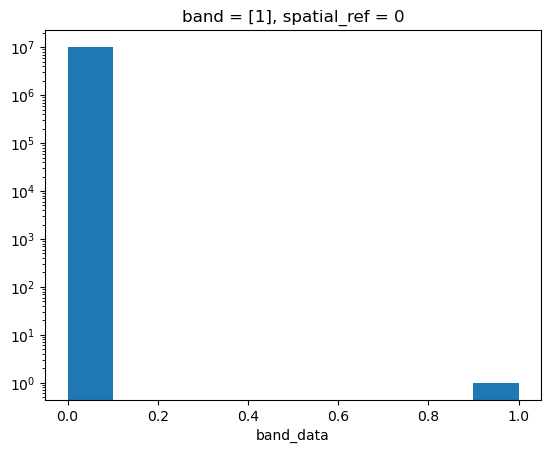

In [144]:
test_diff.band_data.plot.hist(yscale='log')

In [146]:
unique_vals, counts = np.unique(test_diff.band_data.values, return_counts=True)

print(unique_vals)
print(counts)

[0. 1.]
[10239999        1]
